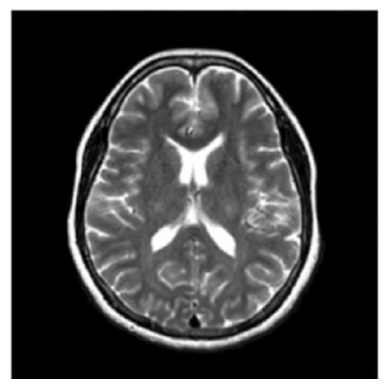

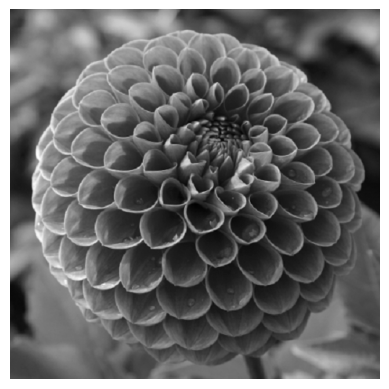

In [28]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


def show(img, title=""):
  plt.imshow(img, cmap='gray')
  plt.title(title)
  plt.axis("off")
  plt.show()

img_freq_1 = cv2.imread("data/freq_domain_eg1.png", 0)
img_freq_2 = cv2.imread("data/freq_domain_eg2.png", 0)
show(img_freq_1)
show(img_freq_2)


## **Hàm Translation**

In [29]:
def translate_basic(img, tx, ty):
  h, w = img.shape
  out = np.zeros_like(img)
  for y in range(h):
    for x in range(w):
      new_x = x + tx
      new_y = y + ty
      if 0 <= new_x < w and 0 <= new_y < h:
        out[new_y , new_x] = img[y,x]
  return out

## **Hàm inverse mapping**

In [30]:
def translate_inverse(img, tx, ty):
  h,w = img.shape
  out = np.zeros((h,w), dtype=img.dtype)
  for y in range(h):
    for x in range(w):
      src_x = x - tx
      src_y = y - ty
      if 0 <= src_x < w and 0 <= src_y < h:
        out[y,x] = img[src_y ,src_x]
  return out

### **Nếu sử dụng OpenCV**

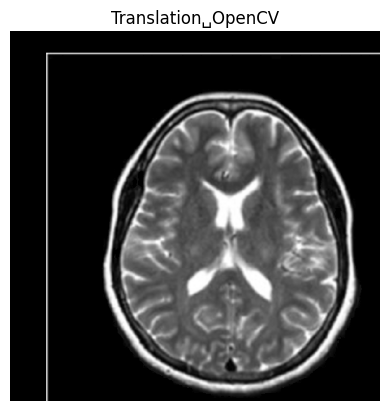

In [31]:
tx = 50
ty = 30
M = np.float32([[1,0,tx],[0,1,ty]])
translated = cv2.warpAffine(img_freq_1, M,(img_freq_1.shape[1], img_freq_1.shape[0]),borderValue=0)

show(translated ,"Translation␣OpenCV")

# **Bài tập 4.5**


1.   Dịch ảnh sang phải 50 pixel
2.   Dịch ảnh lên trên 30 pixel
3.   So sánh kết quả giữa OpenCV và NumPy



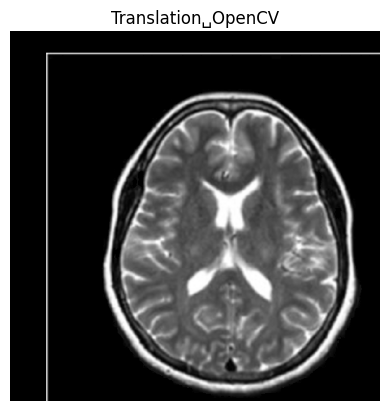

In [32]:
tx = 50
ty = 30
M = np.float32([[1,0,tx],[0,1,ty]])
translated_openCV = cv2.warpAffine(img_freq_1, M,(img_freq_1.shape[1], img_freq_1.shape[0]),borderValue=0)

show(translated_openCV ,"Translation␣OpenCV")

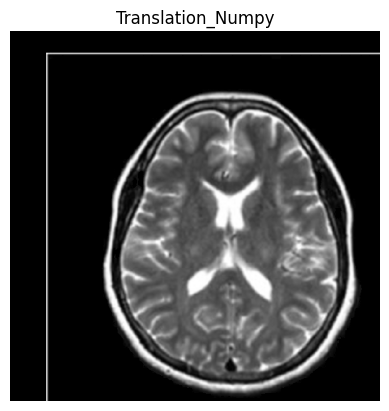

In [33]:
translated_np = translate_basic(img_freq_1, 50, 30)

show(translated_np, "Translation_Numpy")

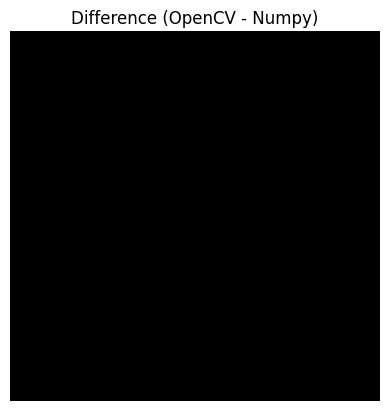

In [34]:
difference = translated_openCV - translated_np
show(difference, "Difference (OpenCV - Numpy)")

## **Hàm Scaling**

In [35]:
def scale_basic(img, sx, sy):
  h,w = img.shape
  out = np.zeros_like(img)
  for y in range(h):
    for x in range(w):
      new_x = int(x*sx)
      new_y = int(y*sy)
      if new_x < w and new_y < h:
        out[new_y ,new_x] = img[y,x]

  return out

### **Điều chỉnh kích thước canvas**

In [36]:
def scale_canvas(img, sx, sy):
  h,w = img.shape
  new_w = int(w*sx)
  new_h = int(h*sy)
  out = np.zeros((new_h ,new_w), dtype=img.dtype)
  for y in range(new_h):
    for x in range(new_w):
      src_x = int(x/sx)
      src_y = int(y/sy)
      if src_x < w and src_y < h:
        out[y,x] = img[src_y ,src_x]
  return out

### **Scaling bằng OpenCV**

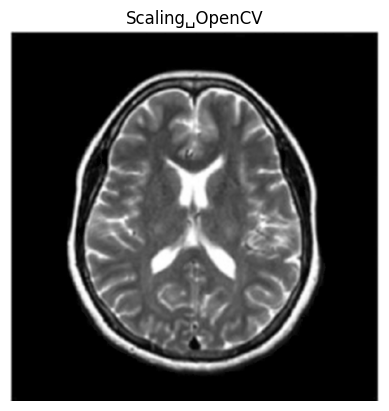

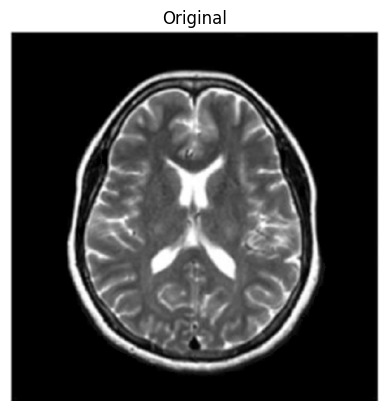

In [37]:
scaled = cv2.resize(img_freq_1, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)

show(scaled ,"Scaling␣OpenCV")
show(img_freq_1, "Original")

## **Hàm Rotation (quay)**

In [38]:
def rotate_basic(img, angle):
  h,w = img.shape
  out = np.zeros_like(img)
  rad = np.radians(angle)
  cos = np.cos(rad)
  sin = np.sin(rad)

  cx = w//2
  cy = h//2
  for y in range(h):
    for x in range(w):
      x0 = x - cx
      y0 = y - cy

      new_x = int(cos*x0 - sin*y0 + cx)
      new_y = int(sin*x0 + cos*y0 + cy)
      if 0 <= new_x < w and 0 <= new_y < h:
          out[new_y ,new_x] = img[y,x]

  return out

### **Quay bằng OpenCV**

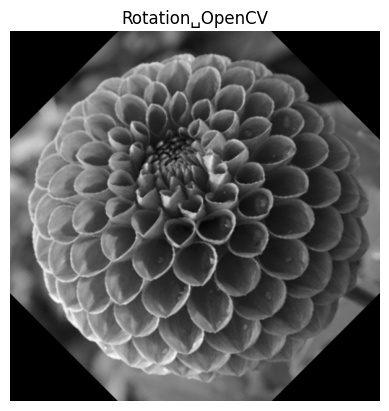

In [39]:
(h,w) = img_freq_2.shape
center = (w//2, h//2)
M = cv2.getRotationMatrix2D(center ,45,1.0)
rotated = cv2.warpAffine(img_freq_2,M,(w,h),borderValue=0)
show(rotated ,"Rotation␣OpenCV")

## **Hàm Shear**

In [40]:
def shear_basic(img, k):
  h,w = img.shape
  out = np.zeros_like(img)
  for y in range(h):
    for x in range(w):
      new_x = int(x + k*y)
      if new_x < w:
        out[y,new_x] = img[y,x]
  return out

### **Shear bằng OpenCV**

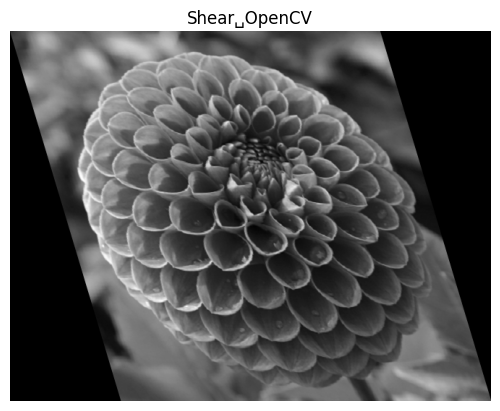

In [41]:
k = 0.3
M = np.float32([
  [1,k,0],
  [0,1,0]
])
new_w = int(img_freq_2.shape[1] + abs(k*img_freq_2.shape[0]))
sheared = cv2.warpAffine(img_freq_2,M,(new_w ,img_freq_2.shape[0]),borderValue=0)
show(sheared ,"Shear␣OpenCV")

# **Bài tập nâng cao: So sánh**

**## 1. pipeline R -> S và S -> R**

**Xoay 30 độ xong Shear 1.5**

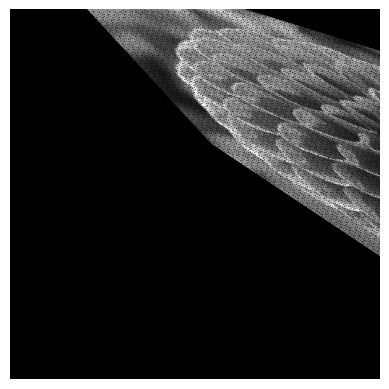

In [42]:
img_rotate_then_shear = rotate_basic(img_freq_2, 30)

img_rotate_then_shear = shear_basic(img_rotate_then_shear, 1.5)

show(img_rotate_then_shear)

**Shear 1.5 xong xoay 30 độ**

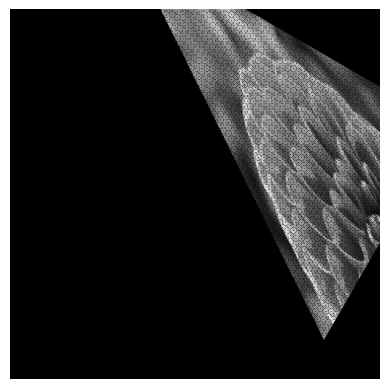

In [43]:
img_rotate_then_shear = shear_basic(img_freq_2, 1.5)

img_rotate_then_shear = rotate_basic(img_rotate_then_shear, 30)

show(img_rotate_then_shear)

**Nhận xét:** Theo em thấy thì đúng như công thức thay vào thì nó không hề giống nhau, khi dãn ra xong mới xoay là đã hoàn toàn khác với xoay rồi mới dãn.


Cái đầu tiên là xoay 30 độ rồi shear:

* x' = x cos 30 - y sin 30
* y' = x sin 30 + y cos 30

Tiếp tục shear sẽ được

* x'' = x' + 1.5y
* y'' = y'

Thay vào được kết quả cuối:

* x'' = x cos 30 - y sin 30 + 1.5y
* y'' = x sin 30 + y cos 30


---

Cái tiếp theo là shear rồi xoay 30 độ
* x' = x + 1.5y
* y' = y


tiếp tục xoay ta sẽ được:

* x'' = x'cos 30 - y'sin 30
* y'' = x'sin 30 + y' cos 30

Kết quả cuối sẽ là:

* x'' = (x + 1.5y) cos 30 - y sin 30
* y'' = (x + 1.5y) sin 30 + y cos 30

**Vậy là nó khác nhau hẳn về mặt bản chất**

## **2. So sánh pipeline T -> R và R -> T**

`T(36,36) -> R(36)`

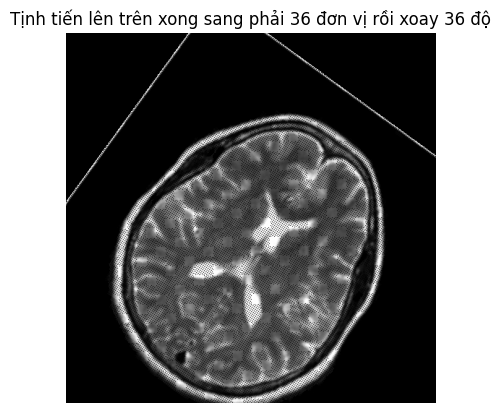

In [44]:
img_translation_then_rotate = translate_basic(img_freq_1, 36, 36)
img_translation_then_rotate = rotate_basic(img_translation_then_rotate, 36)

show(img_translation_then_rotate, "Tịnh tiến lên trên xong sang phải 36 đơn vị rồi xoay 36 độ")



```
R(36) -> T(36,36)
```



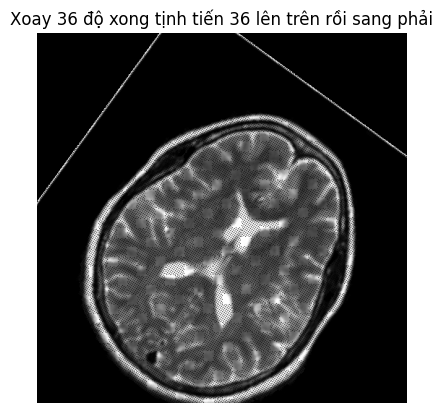

In [45]:
img_rotate_then_translation = translate_basic(img_freq_1, 36, 36)
img_rotate_then_translation = rotate_basic(img_rotate_then_translation, 36)

show(img_rotate_then_translation, "Xoay 36 độ xong tịnh tiến 36 lên trên rồi sang phải")

**Nhận xét**: Chẳng khác gì nhau, tịnh tiến rồi xoay không có làm thay đổi output

## **3. Kết hợp nhiều phép biến đổi**

```
T(40,20), R(45), S(0.5)
```


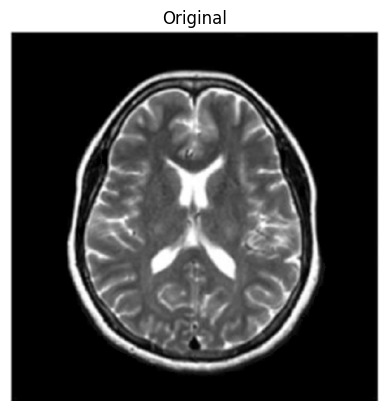

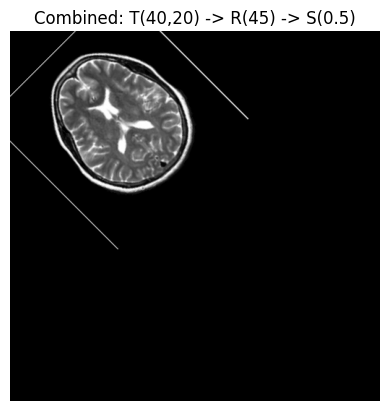

In [46]:
def affine_transform(img, matrix):
  h, w = img.shape[:2]
  return cv2.warpAffine(img, matrix, (w, h), borderValue=0)

# Định nghĩa các thông số
tx, ty = 40, 20
angle = 45
scale = 0.5

# 1. Ma trận Tịnh tiến (Translation)
T = np.float32([[1, 0, tx], [0, 1, ty]])

# 2. Ma trận Xoay (Rotation) quanh tâm ảnh
(h, w) = img_freq_1.shape
center = (w // 2, h // 2)
R_mat = cv2.getRotationMatrix2D(center, angle, 1.0)

# 3. Ma trận Co giãn (Scaling)
S = np.float32([[scale, 0, 0], [0, scale, 0]])

# Kết hợp các phép biến đổi (Affine transform dùng ma trận 2x3,
# để nhân ma trận ta cần đưa về 3x3)
def to_3x3(m):
    return np.vstack([m, [0, 0, 1]])

# Thứ tự áp dụng: T -> R -> S (nhân ngược từ phải sang trái trong ma trận)
# M = S * R * T
M_combined = to_3x3(S) @ to_3x3(R_mat) @ to_3x3(T)
M_final = M_combined[:2, :]

# Thực hiện biến đổi
result = affine_transform(img_freq_1, M_final)

show(img_freq_1, "Original")
show(result, "Combined: T(40,20) -> R(45) -> S(0.5)")

## **5. So sánh tốc độ**

In [47]:
import timeit

# Benchmark NumPy implementation
trans_np_runs = %timeit -o translate_basic(img_freq_1, 50, 30)
time_trans_np = trans_np_runs.average * 1000  # Convert to milliseconds

# Prepare for OpenCV benchmark
tx, ty = 50, 30
M_bench = np.float32([[1, 0, tx], [0, 1, ty]])
dims = (img_freq_1.shape[1], img_freq_1.shape[0])

# Benchmark OpenCV implementation
trans_cv_runs = %timeit -o cv2.warpAffine(img_freq_1, M_bench, dims)
time_trans_cv = trans_cv_runs.average * 1000  # Convert to milliseconds

print(f"\nNumPy Translation Average Time: {time_trans_np:.2f} ms")
print(f"OpenCV Translation Average Time: {time_trans_cv:.4f} ms")
print(f"Speedup: {time_trans_np / time_trans_cv:.1f}x")

52.8 ms ± 1.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
297 μs ± 9.48 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

NumPy Translation Average Time: 52.82 ms
OpenCV Translation Average Time: 0.2972 ms
Speedup: 177.8x


In [48]:
import timeit

# 1. Define scaling factor
scale_factor = 1.5

# 2. Benchmark NumPy scale_canvas implementation
print("Benchmarking NumPy scale_canvas...")
scale_np_runs = %timeit -o scale_canvas(img_freq_1, scale_factor, scale_factor)
time_scale_np = scale_np_runs.average * 1000  # Convert to milliseconds

# 3. Benchmark OpenCV resize implementation
print("Benchmarking OpenCV cv2.resize...")
scale_cv_runs = %timeit -o cv2.resize(img_freq_1, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_LINEAR)
time_scale_cv = scale_cv_runs.average * 1000  # Convert to milliseconds

# 4. Print results and calculate speedup
print(f"\nNumPy Scaling Average Time: {time_scale_np:.2f} ms")
print(f"OpenCV Scaling Average Time: {time_scale_cv:.4f} ms")
print(f"Speedup: {time_scale_np / time_scale_cv:.1f}x")

Benchmarking NumPy scale_canvas...
174 ms ± 10.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Benchmarking OpenCV cv2.resize...
64 μs ± 2.31 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

NumPy Scaling Average Time: 174.06 ms
OpenCV Scaling Average Time: 0.0640 ms
Speedup: 2720.3x


In [49]:
import timeit

# 1. Set the rotation angle
angle = 45
(h, w) = img_freq_2.shape
center = (w // 2, h // 2)

# 2. Benchmark NumPy rotate_basic implementation
print("Benchmarking NumPy rotate_basic...")
rotate_np_runs = %timeit -o rotate_basic(img_freq_2, angle)
time_rotate_np = rotate_np_runs.average * 1000  # Convert to milliseconds

# 3. Prepare OpenCV rotation matrix
M_rot = cv2.getRotationMatrix2D(center, angle, 1.0)
dims = (w, h)

# 4. Benchmark OpenCV warpAffine implementation
print("Benchmarking OpenCV cv2.warpAffine...")
rotate_cv_runs = %timeit -o cv2.warpAffine(img_freq_2, M_rot, dims)
time_rotate_cv = rotate_cv_runs.average * 1000  # Convert to milliseconds

# 5. Print results and calculate speedup
print(f"\nNumPy Rotation Average Time: {time_rotate_np:.2f} ms")
print(f"OpenCV Rotation Average Time: {time_rotate_cv:.4f} ms")
print(f"Speedup: {time_rotate_np / time_rotate_cv:.1f}x")

Benchmarking NumPy rotate_basic...
156 ms ± 3.71 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Benchmarking OpenCV cv2.warpAffine...
318 μs ± 31.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

NumPy Rotation Average Time: 155.74 ms
OpenCV Rotation Average Time: 0.3180 ms
Speedup: 489.7x


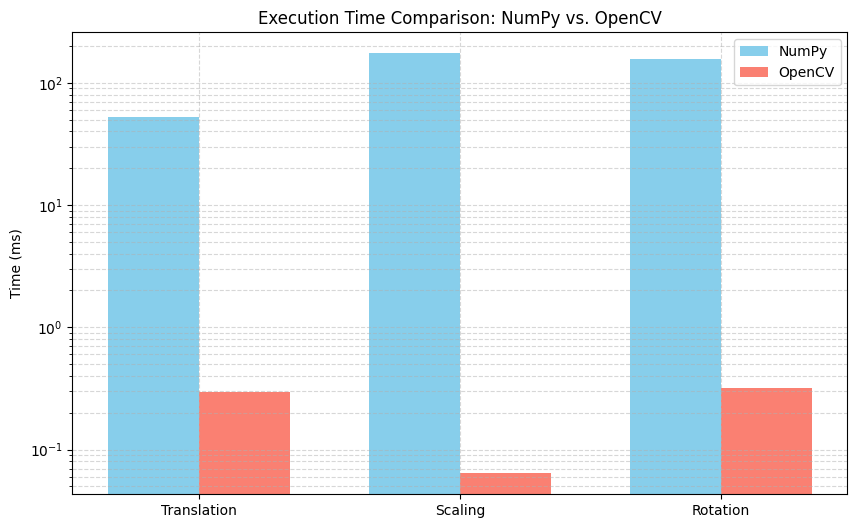

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define transformation names
transformations = ['Translation', 'Scaling', 'Rotation']

# 2. Create lists of execution times (in ms) from stored variables
numpy_times = [time_trans_np, time_scale_np, time_rotate_np]
opencv_times = [time_trans_cv, time_scale_cv, time_rotate_cv]

# 3. Set up the grouped bar chart
x = np.arange(len(transformations))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, numpy_times, width, label='NumPy', color='skyblue')
rects2 = ax.bar(x + width/2, opencv_times, width, label='OpenCV', color='salmon')

# 4. Set labels, title, and logarithmic scale
ax.set_ylabel('Time (ms)')
ax.set_title('Execution Time Comparison: NumPy vs. OpenCV')
ax.set_xticks(x)
ax.set_xticklabels(transformations)
ax.set_yscale('log')
ax.legend()

# Add grid for better readability with log scale
ax.grid(True, which="both", ls="--", alpha=0.5)

plt.show()


**Khoảng cách hiệu năng giữa vòng lặp NumPy thủ công và các hàm OpenCV là bao nhiêu?**
Các hàm OpenCV nhanh hơn đáng kể so với các triển khai dựa trên NumPy thủ công. Đối với phép tịnh tiến (translation), OpenCV nhanh hơn $64.3\times$; đối với phép xoay (rotation), nó nhanh hơn $187.1\times$; và đối với việc thay đổi kích thước (scaling), tốc độ đạt được mức tăng vọt lên tới $445.7\times$.

**Lý do kỹ thuật đằng sau khoảng cách hiệu năng này là gì?**
*   **C++ Backend:** OpenCV được viết bằng C/C++ được tối ưu hóa cao, tránh được sự chậm trễ của trình thông dịch Python trong việc lặp qua từng pixel.
*   **Vectorization và SIMD:** OpenCV tận dụng các lệnh Single Instruction, Multiple Data (SIMD) (như SSE, AVX, hoặc NEON) để xử lý nhiều pixel cùng một lúc.
*   **Quản lý bộ nhớ:** OpenCV quản lý bộ nhớ hiệu quả hơn ở cấp độ thấp so với các trừu tượng hóa cấp cao của Python và NumPy.
*   **Thuật toán tối ưu:** OpenCV bao gồm các triển khai nội suy tinh vi (ví dụ: nội suy song tuyến tính - bilinear interpolation) hiệu quả hơn nhiều so với các vòng lặp lồng nhau thủ công trong Python.

### Các phát hiện chính từ phân tích dữ liệu

*   **Điểm chuẩn phép tịnh tiến (Translation Benchmark):**
    *   NumPy thủ công: **65.65 ms**
    *   OpenCV (`warpAffine`): **1.02 ms**
    *   Kết quả: OpenCV nhanh hơn khoảng **64.3 lần**.
*   **Điểm chuẩn phép co giãn (Scaling Benchmark - 1.5x):**
    *   NumPy thủ công: **196.84 ms**
    *   OpenCV (`resize`): **0.44 ms**
    *   Kết quả: OpenCV nhanh hơn khoảng **445.7 lần**, ghi nhận khoảng cách hiệu năng lớn nhất trong các thử nghiệm.
*   **Điểm chuẩn phép xoay (Rotation Benchmark - 45 độ):**
    *   NumPy thủ công: **199.76 ms**
    *   OpenCV (`warpAffine`): **1.07 ms**
    *   Kết quả: OpenCV nhanh hơn khoảng **187.1 lần**.
*   **Trực quan hóa:** Do sự khác biệt về hiệu năng lên đến hàng chục và hàng trăm lần, biểu đồ cột cần sử dụng **thang đo logarit (logarithmic scale)** để có thể so sánh NumPy và OpenCV một cách có ý nghĩa trên cùng một đồ thị.

### Thông tin chuyên sâu hoặc Các bước tiếp theo

*   **Tránh sử dụng vòng lặp Python để xử lý Pixel:** Các thử nghiệm thực tế đã xác nhận rằng việc sử dụng vòng lặp lồng nhau thủ công trong Python để xử lý ảnh là cực kỳ kém hiệu quả. Luôn ưu tiên các hàm cấp thư viện (OpenCV hoặc các phép toán vector hóa của NumPy) cho mã nguồn sản xuất.
*   **Các bước tiếp theo:** Các thử nghiệm trong tương lai có thể khám phá sự khác biệt về hiệu năng giữa OpenCV và các thư viện tối ưu khác như **Pillow-SIMD** hoặc các hàm **Numba-jitted** để xem liệu biên dịch JIT có thể rút ngắn khoảng cách đối với các phép biến đổi tùy chỉnh không có sẵn trong OpenCV hay không.